# Trabajo de Laboratorio 4: Filtros digitales y FFT

Instalamos numpy y scipy

In [1]:
pip install numpy scipy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1
[notice] To update, run: C:\Users\herra\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

## Ejercicio 2

In [14]:
fs = 10000
fp = 970

# orden
numtaps = 527

# blackman 765
# hamming 545
# hann 800
# bartlett 10000
# boxcar

# ventanas a probar
windows = [
    'boxcar',    # rectangular
    'bartlett',
    'hann',
    'hamming',
    'blackman'
]

win = "hamming"

Ejemplo de filtro con ventana "Hann"

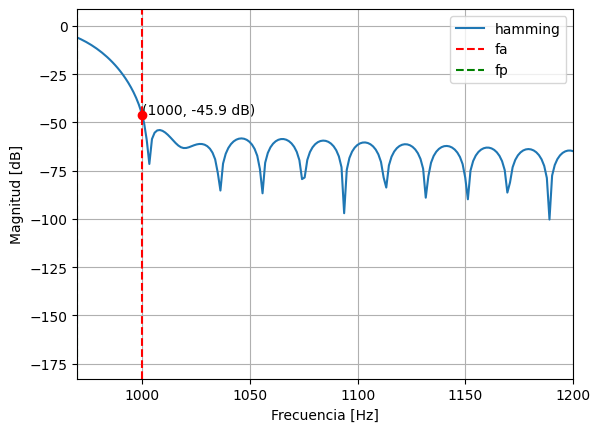

In [15]:
plt.figure()
fs_ds = 2000
fa  = fs_ds / 2

h = signal.firwin(
    numtaps,
    cutoff=fp,
    window=win,
    fs=fs
)


w, H = signal.freqz(h, worN=4096, fs=fs)

H_db = 20*np.log10(np.abs(H) + 1e-12)

plt.plot(w, H_db, label=f"{win}")

y_fa = np.interp(fa, w, H_db)
plt.text(fa, y_fa, f"({fa:.0f}, {y_fa:.1f} dB)")

plt.axvline(fa, linestyle='--', color='red', label='fa')
plt.axvline(fp, linestyle='--', color='green', label='fp')

plt.scatter(fa, y_fa, color='red', zorder=5)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud [dB]")
plt.legend()
plt.xlim(fp, 1.2*fa)
plt.grid()
plt.show()

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

fs = 10000
fp = 970
fa = 1000

windows = ['boxcar', 'bartlett', 'hann', 'hamming', 'blackman']

def cumple_especificacion(numtaps, win):
    h = signal.firwin(numtaps, cutoff=fp, window=win, fs=fs)
    w, H = signal.freqz(h, worN=4096, fs=fs)
    H_db = 20*np.log10(np.abs(H) + 1e-12)
    
    # --- banda de rechazo completa ---
    idx = w >= fa
    H_stop = H_db[idx]
    
    peor_caso = np.max(H_stop)  # peor punto (el más alto en dB)
    
    return peor_caso <= -50, peor_caso

resultados = {}

for win in windows:
    print(f"\nProbando ventana: {win}")
    
    numtaps = 51  # mejor empezar impar
    encontrado = False
    
    while numtaps < 5000:
        ok, peor_caso = cumple_especificacion(numtaps, win)
        
        if ok:
            print(f"✔ Cumple con {numtaps} taps (peor caso ≥1000Hz = {peor_caso:.2f} dB)")
            resultados[win] = numtaps
            encontrado = True
            break
        
        numtaps += 2  # mantener impar
    
    if not encontrado:
        print("❌ No cumple en el rango probado")

print("\nResumen:")
for win, taps in resultados.items():
    print(f"{win}: {taps} taps")


Probando ventana: boxcar
❌ No cumple en el rango probado

Probando ventana: bartlett
❌ No cumple en el rango probado

Probando ventana: hann
✔ Cumple con 761 taps (peor caso ≥1000Hz = -50.10 dB)

Probando ventana: hamming
✔ Cumple con 527 taps (peor caso ≥1000Hz = -50.22 dB)

Probando ventana: blackman
✔ Cumple con 741 taps (peor caso ≥1000Hz = -50.21 dB)

Resumen:
hann: 761 taps
hamming: 527 taps
blackman: 741 taps


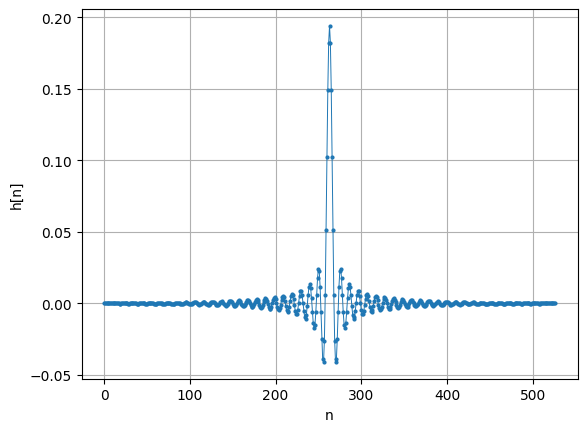

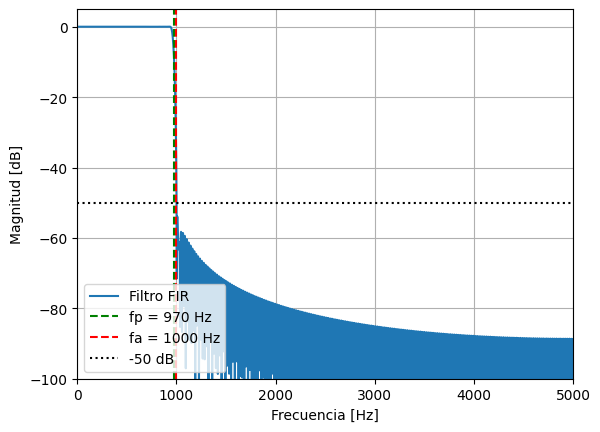

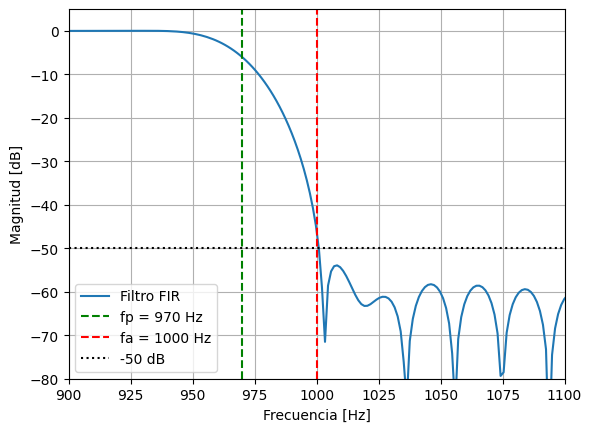

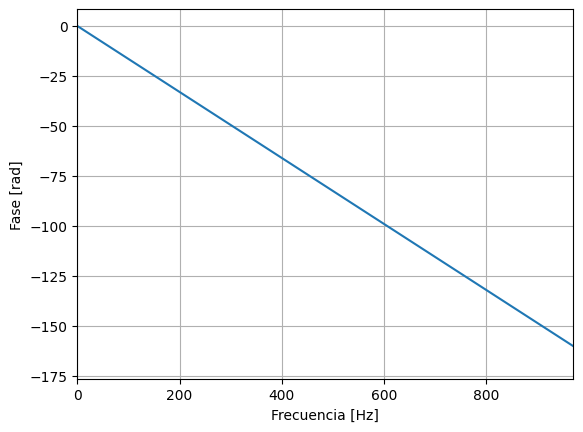

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# --- parámetros ---
fs = 10000
fp = 970
fa = 1000
numtaps = 527
win = 'hamming'

# --- diseño del filtro ---
h = signal.firwin(numtaps, cutoff=fp, window=win, fs=fs)

# --- respuesta en frecuencia ---
w, H = signal.freqz(h, worN=4096, fs=fs)
H_db = 20*np.log10(np.abs(H) + 1e-12)
H_phase = np.unwrap(np.angle(H))

# --- peor caso en banda de rechazo ---
idx_stop = w >= fa
H_stop = H_db[idx_stop]
w_stop = w[idx_stop]

peor_valor = np.max(H_stop)
peor_freq = w_stop[np.argmax(H_stop)]

# =========================
# 1) RESPUESTA IMPULSIVA
# =========================
plt.figure()
plt.plot(h, marker='o', markersize=2, linewidth=0.7)
plt.xlabel("n")
plt.ylabel("h[n]")
plt.grid()

# =========================
# 2) MAGNITUD COMPLETA
# =========================
plt.figure()
plt.plot(w, H_db, label='Filtro FIR')

plt.axvline(fp, color='green', linestyle='--', label='fp = 970 Hz')
plt.axvline(fa, color='red', linestyle='--', label='fa = 1000 Hz')
plt.axhline(-50, color='black', linestyle=':', label='-50 dB')

plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud [dB]")
plt.xlim(0, fs/2)
plt.ylim(-100, 5)
plt.legend(loc='lower left')
plt.grid()

# =========================
# 3) ZOOM TRANSICIÓN
# =========================
plt.figure()
plt.plot(w, H_db, label='Filtro FIR')

plt.axvline(fp, color='green', linestyle='--', label='fp = 970 Hz')
plt.axvline(fa, color='red', linestyle='--', label='fa = 1000 Hz')
plt.axhline(-50, color='black', linestyle=':', label='-50 dB')

plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud [dB]")
plt.xlim(900, 1100)
plt.ylim(-80, 5)
plt.legend(loc='lower left')
plt.grid()

# =========================
# 4) FASE
# =========================
plt.figure()
plt.plot(w, H_phase)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Fase [rad]")
plt.xlim(0, fp)
plt.grid()

plt.show()

Señal de entrada de prueba

In [31]:
fs = 10000
f = 600
t = np.arange(0, 10, 1/fs)
x = signal.square(2*np.pi*600*t)

(0.0, 0.06)

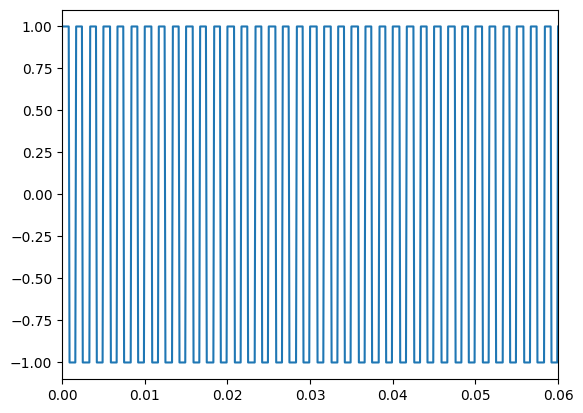

In [30]:
plt.plot(t, x)
plt.xlim(0, 600/fs)

Escriba su función de procesamiento FIR acá

In [39]:
import numpy as np
import time

def fir_filter(x, h):
    x = np.asarray(x)
    h = np.asarray(h)
    
    N = len(h)
    L = len(x)
    
    y = np.zeros(L)
    
    #Debemos realizar la convolución de h y x
    for n in range(L):
        for k in range(N):
            if n-k>=0:
                y[n] += h[k] * x[n-k]

    return y

In [ ]:
# --- filtrado ---
y = fir_filter(x, h)

#--- down-sampling ---
N_ds = 5

y_ds = y[::N_ds]
t_ds = t[::N_ds]

In [75]:
n_runs = 5
tiempos = []

for _ in range(n_runs):
    start = time.perf_counter()
    y = fir_filter(x, h)
    end = time.perf_counter()
    
    tiempos.append(end - start)

t_total = np.mean(tiempos)
t_por_muestra = t_total / len(x)

print(f"Tiempo total promedio: {t_total:.6f} s")
print(f"Tiempo por muestra: {t_por_muestra*1e6:.3f} us")

for i, t in enumerate(tiempos):
    print(f"Corrida {i+1}: {t:.6f} s")

Tiempo total promedio: 18.480776 s
Tiempo por muestra: 184.808 us
Corrida 1: 19.135894 s
Corrida 2: 18.456400 s
Corrida 3: 18.152865 s
Corrida 4: 18.438790 s
Corrida 5: 18.219928 s


In [ ]:
print(tiempos)

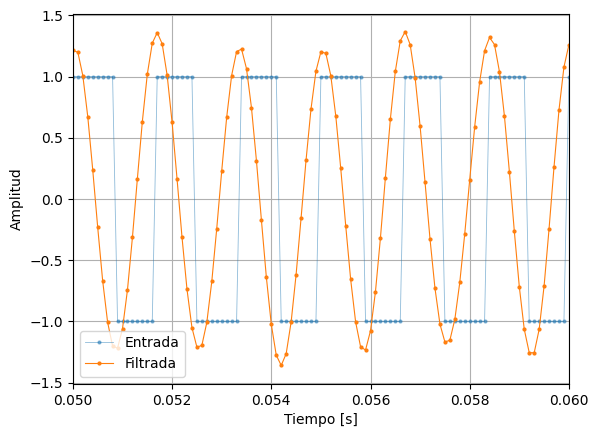

In [49]:
delay = (len(h) - 1) // 2

y_aligned = y[delay:]
t_aligned = t[delay:]

plt.figure()

plt.plot(t_aligned, x[delay:],
         marker='o', markersize=2,
         linewidth=0.6,
         alpha=0.5,
         label='Entrada')

plt.plot(t_aligned, y_aligned,
         marker='o', markersize=2,
         linewidth=0.8,
         label='Filtrada')

plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.xlim(0.05, 0.06)
plt.legend()
plt.grid()

plt.show()

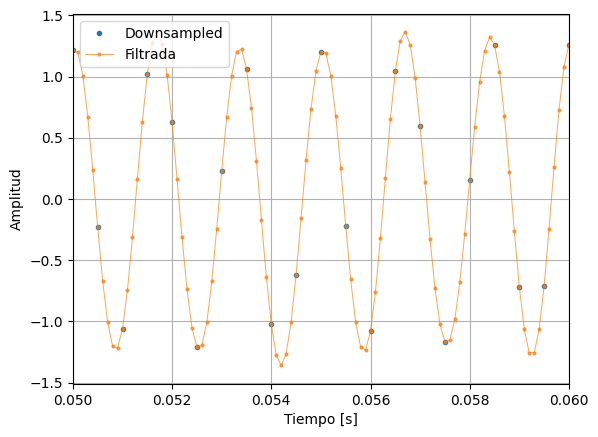

In [56]:
plt.figure()

plt.plot(t_ds, y_ds,
         marker='o', linestyle='none',
         markersize=3,
         label='Downsampled')

plt.plot(t, y,
         marker='o', markersize=2,
         linewidth=0.7,
         alpha=0.7,
         label='Filtrada')



plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.xlim(0.05, 0.06)
plt.legend()
plt.grid()

plt.show()

In [85]:
# --- ventana ---
win = np.hanning(len(x))
x_win = x * win

# --- FFT ---
X = np.fft.fft(x_win)
X = np.abs(X) / len(X)   # normalización

freq = np.fft.fftfreq(len(X), d=1/fs)

# solo frecuencias positivas
idx = freq >= 0
freq = freq[idx]
X = X[idx]

# --- ventana ---
win_y = np.hanning(len(y))
y_win = y * win_y

# --- FFT ---
Y = np.fft.fft(y_win)
Y = np.abs(Y) / len(Y)

freq_y = np.fft.fftfreq(len(Y), d=1/fs)

# solo frecuencias positivas
idx = freq_y >= 0
freq_y = freq_y[idx]
Y = Y[idx]


# --- ventana ---
win_y_ds = np.hanning(len(y_ds))
y_win_ds = y_ds * win_y_ds

# --- FFT ---
Y_ds = np.fft.fft(y_win_ds)
Y_ds = np.abs(Y_ds) / len(Y_ds)

freq_y_ds = np.fft.fftfreq(len(Y_ds), d=1/fs_ds)

# solo frecuencias positivas
idx = freq_y_ds >= 0
freq_y_ds = freq_y_ds[idx]
Y_ds = Y_ds[idx]


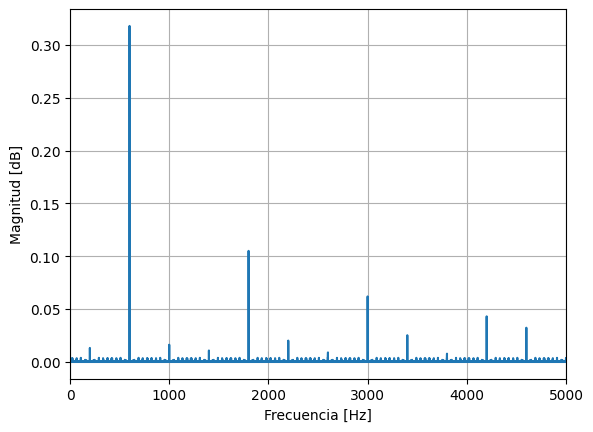

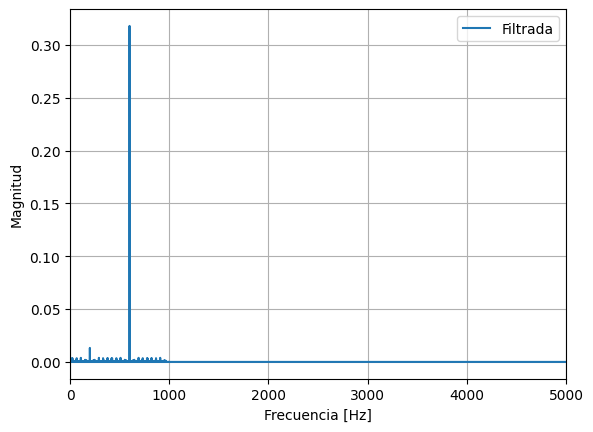

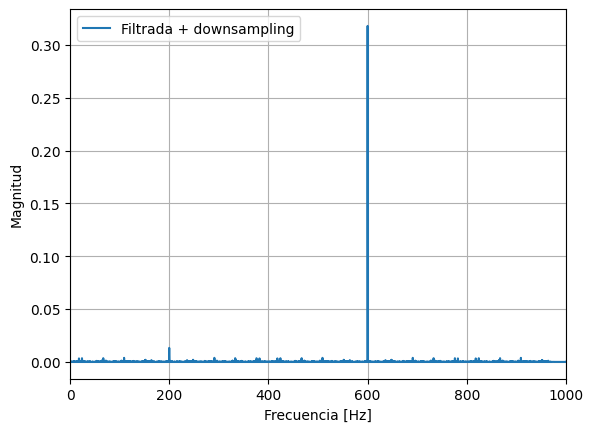

In [87]:
plt.figure()
plt.plot(freq, X)

plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud [dB]")
plt.xlim(0, 5000)
plt.grid()

plt.show()

plt.figure()
plt.plot(freq_y, Y, label='Filtrada')

plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.xlim(0, 5000)
plt.legend()
plt.grid()

plt.show()

plt.figure()
plt.plot(freq_y_ds, Y_ds, label='Filtrada + downsampling')

plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.xlim(0, 1000)
plt.legend()
plt.grid()

plt.show()

## Ejercicio 3: FIR aplicando Overlap and Save

In [129]:
import numpy as np
import time

def overlap_save_fir(x, h, L=1024):
    x = np.asarray(x)
    h = np.asarray(h)
    
    N = len(h)
    K =             # tamaño FFT
    
    # Complete su código acá

    return y

SyntaxError: invalid syntax (3511122254.py, line 9)

In [ ]:
# Overlap-Save
y = overlap_save_fir(x, h, L=1024)

In [ ]:
y_ref = y

In [ ]:
import numpy as np
import time

# --- Datos de entrada (asumiendo que ya existen) ---
# h: tus 527 coeficientes
# x: tu señal de entrada
# y_ref: el resultado de ejercicio 1 (convolución lineal) para comparar

L = 1024
M = len(h)
N = 2048  # Potencia de 2 recomendada para h=527 y L=1024

# 1. Pre-cálculo: FFT del filtro (solo una vez)
H = np.fft.fft(h, n=N)

# Inicialización
salida_final = []
tiempos_bloque = []
pasado = np.zeros(M - 1) # M-1 ceros iniciales

# 2. Procesamiento por bloques
for i in range(0, len(x), L):
    start_time = time.perf_counter()
    
    # Tomamos el bloque actual de la señal
    bloque_actual = x[i : i + L]
    
    # Si el último bloque es más chico que L, lo rellenamos con ceros
    if len(bloque_actual) < L:
        bloque_actual = np.pad(bloque_actual, (0, L - len(bloque_actual)))
    
    # Armado del bloque de entrada N=2048: [pasado(526) + actual(1024) + ceros(498)]
    # Usamos np.concatenate o simplemente pasamos el tamaño a np.fft.fft
    entrada_fft = np.concatenate([pasado, bloque_actual])
    
    # Procesamiento espectral
    X = np.fft.fft(entrada_fft, n=N)
    Y = X * H
    y_bloque = np.fft.ifft(Y).real # Nos quedamos con la parte real
    
    # --- OVERLAP AND SAVE: Salvar desde el índice M-1 hasta (M-1 + L) ---
    # Esto extrae exactamente las 1024 muestras limpias
    bloque_limpio = y_bloque[M-1 : M-1+L]
    salida_final.extend(bloque_limpio)
    
    # Actualizamos el pasado para la siguiente iteración
    pasado = bloque_actual[-(M-1):]
    
    end_time = time.perf_counter()
    tiempos_bloque.append(end_time - start_time)

# 3. Mediciones y Comparación
salida_final = np.array(salida_final[:len(x)]) # Recortamos al largo original si es necesario
tiempo_total = sum(tiempos_bloque)
tiempo_por_muestra = tiempo_total / len(x)

print(f"Tiempo total: {tiempo_total:.4f} s")
print(f"Tiempo por muestra: {tiempo_por_muestra:.8f} s")

# Comparación con el ejercicio 1 (y_ref)
# Nota: y_ref debe ser recortado o comparado hasta len(x)
error = np.linalg.norm(salida_final - y_ref[:len(x)])
print(f"Error acumulado contra convolución: {error}")

Tiempo total: 0.0380 s
Tiempo por muestra: 0.00000038 s
Error acumulado contra convolución: 2.2228203505445087e-13


## Ejercicio 3: THD

### Comb

C:\Users\herra\AppData\Local\Temp\ipykernel_93928\3985673799.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


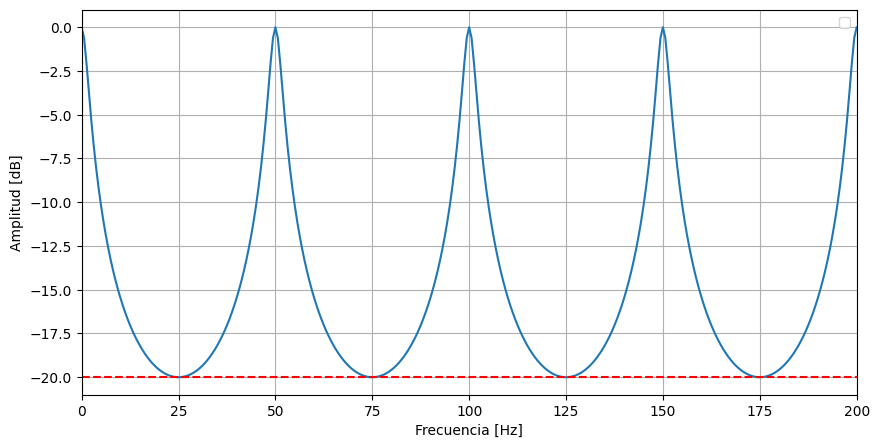

In [91]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import lfilter, freqz

# Parámetros del diseño según tu análisis
fs = 10000          # Frecuencia de muestreo (10 kHz)
f0 = 50             # Frecuencia fundamental (Hz)
k = int(fs / f0)    # Retraso (200 muestras)

# Coeficientes calculados
beta = 9/11
alpha = 2/11

# --- Definición del filtro ---
# La ecuación y[n] = alpha*x[n] + beta*y[n-k] se traduce a:
# y[n] - beta*y[n-k] = alpha*x[n]
# Coeficientes del numerador (b): alpha en la posición 0, luego k ceros
b = np.zeros(k + 1)
b[0] = alpha

# Coeficientes del denominador (a): 1 en la pos 0, -beta en la pos k
a = np.zeros(k + 1)
a[0] = 1.0
a[k] = -beta

# --- Análisis de Respuesta en Frecuencia ---
w, h = freqz(b, a, worN=8000, fs=fs)

# Graficar
plt.figure(figsize=(10, 5))
plt.plot(w, 20 * np.log10(np.abs(h)))
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Amplitud [dB]')
plt.grid(True)
plt.axhline(-20, color='red', linestyle='--')
plt.xlim(0, 200) # Zoom a las primeras componentes
plt.legend()
plt.show()

# --- Ejemplo de uso con una señal ---
# x = señal_de_entrada
# y1 = lfilter(b, a, x)

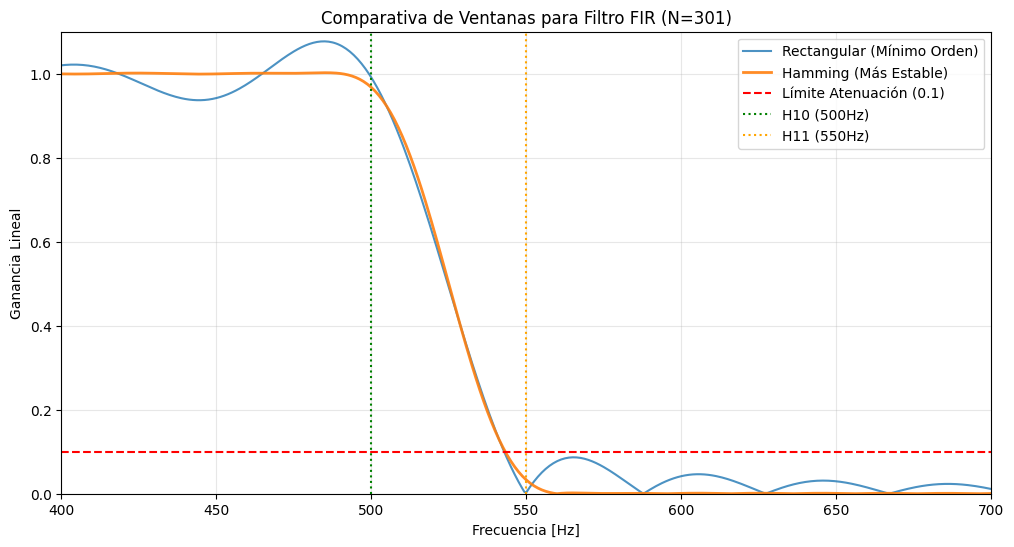

In [108]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

fs = 10000
numtaps_rect = 251
numtaps_hamming = 501
fc = 525

# Diseño de ambos filtros
taps_rect = signal.firwin(numtaps_rect, fc, fs=fs, window='boxcar')
taps_hamm = signal.firwin(numtaps_hamming, fc, fs=fs, window='hamming')

# Respuestas en frecuencia
w, h_rect = signal.freqz(taps_rect, [1], worN=8000, fs=fs)
w, h_hamm = signal.freqz(taps_hamm, [1], worN=8000, fs=fs)

# Graficar
plt.figure(figsize=(12, 6))

plt.plot(w, np.abs(h_rect), label='Rectangular (Mínimo Orden)', alpha=0.8, linewidth=1.5)
plt.plot(w, np.abs(h_hamm), label='Hamming (Más Estable)', alpha=0.9, linewidth=2)

plt.axhline(0.1, color='red', linestyle='--', label='Límite Atenuación (0.1)')
plt.axvline(500, color='green', linestyle=':', label='H10 (500Hz)')
plt.axvline(550, color='orange', linestyle=':', label='H11 (550Hz)')

plt.title(f'Comparativa de Ventanas para Filtro FIR (N={numtaps})')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Ganancia Lineal')
plt.xlim(400, 700)  # Zoom en la zona crítica de transición
plt.ylim(0, 1.1)
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.show()

In [147]:
# Definimos los armónicos de interés (del 1 al 11)
armonicos = np.arange(50, 600, 50)

# Función para obtener la ganancia en frecuencias específicas
def obtener_ganancias(w, h, freqs):
    # Interpolamos la magnitud (np.abs(h)) en las frecuencias deseadas
    return np.interp(freqs, w, np.abs(h))

ganancias_rect = obtener_ganancias(w, h_rect, armonicos)
ganancias_hamm = obtener_ganancias(w, h_hamm, armonicos)

# Mostrar resultados
print(f"{'Frec [Hz]':<10} | {'Rect (N=201)':<15} | {'Hamming (N=01)':<15}")
print("-" * 45)
for i, f in enumerate(armonicos):
    print(f"{f:<10} | {ganancias_rect[i]:<15.4f} | {ganancias_hamm[i]:<15.4f}")

Frec [Hz]  | Rect (N=201)    | Hamming (N=01) 
---------------------------------------------
50         | 0.9772          | 1.0003         
100        | 0.9879          | 1.0007         
150        | 0.9959          | 1.0005         
200        | 0.9713          | 0.9999         
250        | 1.0013          | 1.0001         
300        | 0.9828          | 1.0009         
350        | 0.9733          | 1.0008         
400        | 1.0200          | 0.9995         
450        | 0.9420          | 0.9996         
500        | 0.9911          | 0.9675         
550        | 0.0030          | 0.0328         


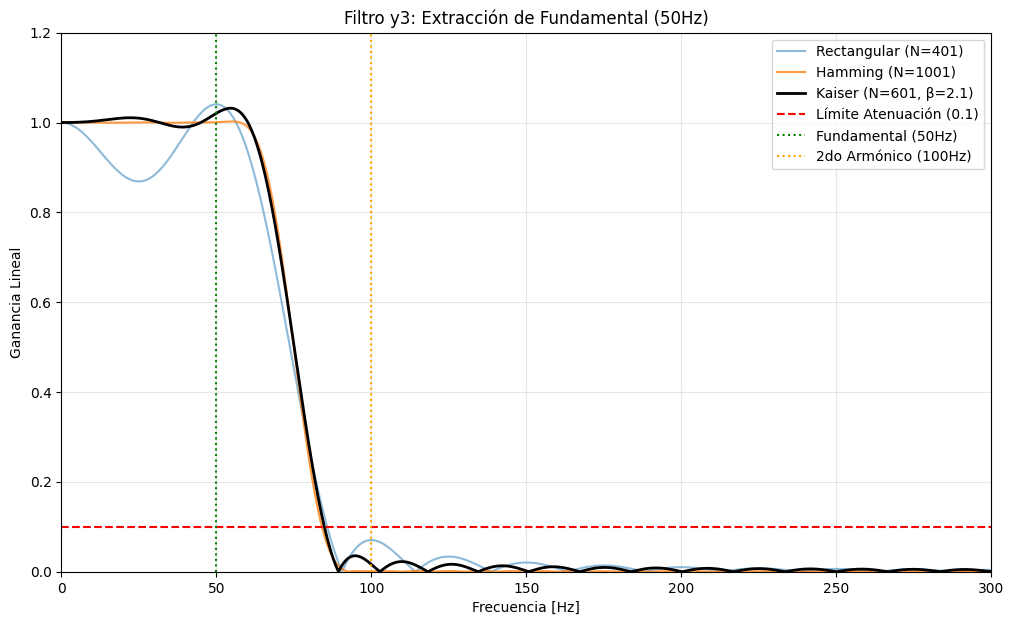

Armónico     | Frec [Hz]  | Rect       | Rect Comp.   | Hamming    | Kaiser    
-------------------------------------------------------------------------------------
H1          | 50         | 1.0407     | 1.0000       | 1.0008     | 1.0205    
H2          | 100        | 0.0704     | 0.0677       | 0.0008     | 0.0165    
H3          | 150        | 0.0205     | 0.0197       | 0.0000     | 0.0018    
H4          | 200        | 0.0102     | 0.0098       | 0.0000     | 0.0005    
H5          | 250        | 0.0062     | 0.0060       | 0.0000     | 0.0001    
H6          | 300        | 0.0042     | 0.0041       | 0.0000     | 0.0001    
H7          | 350        | 0.0031     | 0.0029       | 0.0000     | 0.0002    
H8          | 400        | 0.0023     | 0.0022       | 0.0000     | 0.0003    
H9          | 450        | 0.0018     | 0.0017       | 0.0000     | 0.0003    
H10         | 500        | 0.0015     | 0.0014       | 0.0000     | 0.0003    
H11         | 550        | 0.0012     | 0.00

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# --- Configuración Inicial ---
fs = 10000
fc = 75  # Corte en el punto medio entre 50Hz (H1) y 100Hz (H2)
armonicos = np.arange(50, 601, 50)

# --- Órdenes Óptimos para recuperar la Fundamental ---
# Nota: Los órdenes suben porque la banda de transición es de solo 50Hz
n_rect = 401   
n_hamm = 1001  
n_kais = 501   
beta_k = 2.1  # Beta bajo para maximizar pendiente

# --- Diseño de Filtros ---
taps_rect = signal.firwin(n_rect, fc, fs=fs, window='boxcar')
taps_hamm = signal.firwin(n_hamm, fc, fs=fs, window='hamming')
taps_kais = signal.firwin(n_kais, fc, fs=fs, window=('kaiser', beta_k))

# --- Respuesta en Frecuencia ---
def get_response(taps):
    w, h = signal.freqz(taps, [1], worN=20000, fs=fs)
    return w, h

w_r, h_r = get_response(taps_rect)
w_h, h_h = get_response(taps_hamm)
w_k, h_k = get_response(taps_kais)

# --- Función para obtener ganancias ---
def check_gain(w, h, freqs):
    return np.interp(freqs, w, np.abs(h))

g_rect = check_gain(w_r, h_r, armonicos)
g_hamm = check_gain(w_h, h_h, armonicos)
g_kais = check_gain(w_k, h_k, armonicos)

# --- COMPENSACIÓN RECTANGULAR ---
# Calculamos el factor para que la ganancia en 50Hz sea exactamente 1.0
factor_comp = 1.0 / g_rect[0]
g_rect_comp = g_rect * factor_comp

# --- 1. Gráfica Comparativa ---
plt.figure(figsize=(12, 7))

plt.plot(w_r, np.abs(h_r), label=f'Rectangular (N={n_rect})', alpha=0.5)
plt.plot(w_h, np.abs(h_h), label=f'Hamming (N={n_hamm})', alpha=0.8)
plt.plot(w_k, np.abs(h_k), label=f'Kaiser (N={n_kais}, β={beta_k})', color='black', linewidth=2)

plt.axhline(0.1, color='red', linestyle='--', label='Límite Atenuación (0.1)')
plt.axvline(50, color='green', linestyle=':', label='Fundamental (50Hz)')
plt.axvline(100, color='orange', linestyle=':', label='2do Armónico (100Hz)')

plt.title('Filtro y3: Extracción de Fundamental (50Hz)')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Ganancia Lineal')
plt.xlim(0, 300)  # Zoom en la zona de la fundamental
plt.ylim(0, 1.2)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# --- 2. Tabla de Resultados ---
print(f"{'Armónico':<12} | {'Frec [Hz]':<10} | {'Rect':<10} | {'Rect Comp.':<12} | {'Hamming':<10} | {'Kaiser':<10}")
print("-" * 85)
for i, f in enumerate(armonicos):
    h_num = f // 50
    print(f"H{h_num:<10} | {f:<10} | {g_rect[i]:<10.4f} | {g_rect_comp[i]:<12.4f} | {g_hamm[i]:<10.4f} | {g_kais[i]:<10.4f}")

# --- 3. Reporte de Error en la Fundamental (H1) ---
err_r = np.abs(1 - g_rect[0]) * 100
err_rc = np.abs(1 - g_rect_comp[0]) * 100
err_h = np.abs(1 - g_hamm[0]) * 100
err_k = np.abs(1 - g_kais[0]) * 100

print(f"\n{'Métrica':<20} | {'Rect':<10} | {'Rect Comp':<10} | {'Hamming':<10} | {'Kaiser':<10}")
print("-" * 70)
print(f"{'Error en 50Hz [%]':<20} | {err_r:<10.4f} | {err_rc:<10.4f} | {err_h:<10.4f} | {err_k:<10.4f}")
print(f"{'Ganancia en 100Hz':<20} | {g_rect[1]:<10.4f} | {g_rect_comp[1]:<10.4f} | {g_hamm[1]:<10.4f} | {g_kais[1]:<10.4f}")
print(f"{'CUMPLE ATEN. H2':<20} | {str(g_rect_comp[1]<0.1):<10} | {str(g_rect_comp[1]<0.1):<10} | {str(g_hamm[1]<0.1):<10} | {str(g_kais[1]<0.1):<10}")

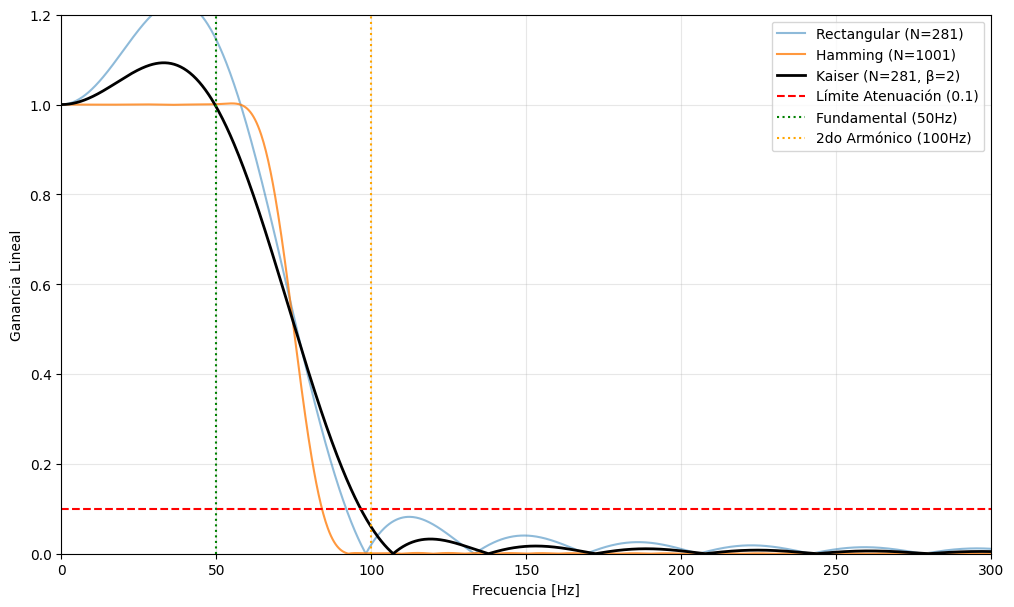

Armónico     | Frec [Hz]  | Rect       | Rect Comp.   | Hamming    | Kaiser    
-------------------------------------------------------------------------------------
H1          | 50         | 1.1443     | 1.0000       | 1.0008     | 0.9945    
H2          | 100        | 0.0204     | 0.0179       | 0.0008     | 0.0591    
H3          | 150        | 0.0404     | 0.0353       | 0.0000     | 0.0164    
H4          | 200        | 0.0105     | 0.0092       | 0.0000     | 0.0063    
H5          | 250        | 0.0101     | 0.0088       | 0.0000     | 0.0036    
H6          | 300        | 0.0110     | 0.0096       | 0.0000     | 0.0048    
H7          | 350        | 0.0002     | 0.0001       | 0.0000     | 0.0004    
H8          | 400        | 0.0073     | 0.0064       | 0.0000     | 0.0030    
H9          | 450        | 0.0044     | 0.0038       | 0.0000     | 0.0020    
H10         | 500        | 0.0030     | 0.0026       | 0.0000     | 0.0011    
H11         | 550        | 0.0052     | 0.00

In [164]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# --- Configuración Inicial ---
fs = 10000
fc = 75  # Corte en el punto medio entre 50Hz (H1) y 100Hz (H2)
armonicos = np.arange(50, 601, 50)

# --- Órdenes Óptimos para recuperar la Fundamental ---
# Nota: Los órdenes suben porque la banda de transición es de solo 50Hz
n_rect = 281   
n_hamm = 1001  
n_kais = 281   
beta_k = 2  # Beta bajo para maximizar pendiente

# --- Diseño de Filtros ---
taps_rect = signal.firwin(n_rect, fc, fs=fs, window='boxcar')
taps_hamm = signal.firwin(n_hamm, fc, fs=fs, window='hamming')
taps_kais = signal.firwin(n_kais, fc, fs=fs, window=('kaiser', beta_k))

# --- Respuesta en Frecuencia ---
def get_response(taps):
    w, h = signal.freqz(taps, [1], worN=20000, fs=fs)
    return w, h

w_r, h_r = get_response(taps_rect)
w_h, h_h = get_response(taps_hamm)
w_k, h_k = get_response(taps_kais)

# --- Función para obtener ganancias ---
def check_gain(w, h, freqs):
    return np.interp(freqs, w, np.abs(h))

g_rect = check_gain(w_r, h_r, armonicos)
g_hamm = check_gain(w_h, h_h, armonicos)
g_kais = check_gain(w_k, h_k, armonicos)

# --- COMPENSACIÓN RECTANGULAR ---
# Calculamos el factor para que la ganancia en 50Hz sea exactamente 1.0
factor_comp = 1.0 / g_rect[0]
g_rect_comp = g_rect * factor_comp

# --- 1. Gráfica Comparativa ---
plt.figure(figsize=(12, 7))

plt.plot(w_r, np.abs(h_r), label=f'Rectangular (N={n_rect})', alpha=0.5)
plt.plot(w_h, np.abs(h_h), label=f'Hamming (N={n_hamm})', alpha=0.8)
plt.plot(w_k, np.abs(h_k), label=f'Kaiser (N={n_kais}, β={beta_k})', color='black', linewidth=2)

plt.axhline(0.1, color='red', linestyle='--', label='Límite Atenuación (0.1)')
plt.axvline(50, color='green', linestyle=':', label='Fundamental (50Hz)')
plt.axvline(100, color='orange', linestyle=':', label='2do Armónico (100Hz)')


plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Ganancia Lineal')
plt.xlim(0, 300)  # Zoom en la zona de la fundamental
plt.ylim(0, 1.2)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# --- 2. Tabla de Resultados ---
print(f"{'Armónico':<12} | {'Frec [Hz]':<10} | {'Rect':<10} | {'Rect Comp.':<12} | {'Hamming':<10} | {'Kaiser':<10}")
print("-" * 85)
for i, f in enumerate(armonicos):
    h_num = f // 50
    print(f"H{h_num:<10} | {f:<10} | {g_rect[i]:<10.4f} | {g_rect_comp[i]:<12.4f} | {g_hamm[i]:<10.4f} | {g_kais[i]:<10.4f}")

# --- 3. Reporte de Error en la Fundamental (H1) ---
err_r = np.abs(1 - g_rect[0]) * 100
err_rc = np.abs(1 - g_rect_comp[0]) * 100
err_h = np.abs(1 - g_hamm[0]) * 100
err_k = np.abs(1 - g_kais[0]) * 100

print(f"\n{'Métrica':<20} | {'Rect':<10} | {'Rect Comp':<10} | {'Hamming':<10} | {'Kaiser':<10}")
print("-" * 70)
print(f"{'Error en 50Hz [%]':<20} | {err_r:<10.4f} | {err_rc:<10.4f} | {err_h:<10.4f} | {err_k:<10.4f}")
print(f"{'Ganancia en 100Hz':<20} | {g_rect[1]:<10.4f} | {g_rect_comp[1]:<10.4f} | {g_hamm[1]:<10.4f} | {g_kais[1]:<10.4f}")
print(f"{'CUMPLE ATEN. H2':<20} | {str(g_rect_comp[1]<0.1):<10} | {str(g_rect_comp[1]<0.1):<10} | {str(g_hamm[1]<0.1):<10} | {str(g_kais[1]<0.1):<10}")

In [201]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# --- 1. TUS PARÁMETROS ORIGINALES ---
fs = 10000
BUFFER_SIZE = 1024
OFFSET = 2048
f0 = 50

# Coeficientes Kaiser (TAL CUAL LOS TENÍAS)
n2, beta2, fc2 = 281, 1.8, 530
taps_y2 = signal.firwin(n2, fc2, fs=fs, window=('kaiser', beta2))

n3, beta3, fc3 = 281, 2.0, 75
taps_y3 = signal.firwin(n3, fc3, fs=fs, window=('kaiser', beta3))

alpha, beta, k_delay = 2/11, 9/11, 200

# --- 2. GENERACIÓN DE SEÑAL (Cambiamos a Cuadrada para la prueba 3.3.b) ---
duration = 2.0 
t = np.arange(0, duration, 1/fs)
x_cont = signal.square(2 * np.pi * f0 * t)
x_adc = (x_cont * 1500 + OFFSET).astype(np.uint16)

# --- 3. VARIABLES DE ESTADO (static en C) ---
state_comb = np.zeros(k_delay)
ptr_comb = 0
state_y2 = np.zeros(len(taps_y2))
state_y3 = np.zeros(len(taps_y3))

def my_app_simulation(adc_buffer):
    global ptr_comb, state_comb, state_y2, state_y3
    y1, y2, y3 = np.zeros(BUFFER_SIZE), np.zeros(BUFFER_SIZE), np.zeros(BUFFER_SIZE)
    
    for i in range(BUFFER_SIZE):
        x_n = float(adc_buffer[i]) - OFFSET
        
        # Filtro Comb (Tu implementación)
        y1_n = alpha * x_n + beta * state_comb[ptr_comb]
        state_comb[ptr_comb] = y1_n
        ptr_comb = (ptr_comb + 1) % k_delay
        y1[i] = y1_n
        
        # Filtros FIR (Tu implementación con tus taps)
        # Shift manual como harías en C
        state_y2 = np.roll(state_y2, 1); state_y2[0] = y1_n
        y2[i] = np.dot(state_y2, taps_y2)
        
        state_y3 = np.roll(state_y3, 1); state_y3[0] = y1_n
        y3[i] = np.dot(state_y3, taps_y3)
        
    # --- CÁLCULO RMS ---
    vt_rms = np.sqrt(np.mean(y2**2))
    v0_rms = np.sqrt(np.mean(y3**2))
    
    # THD
    thd = (np.sqrt(max(0, vt_rms**2 - v0_rms**2)) / v0_rms) * 100 if v0_rms > 1 else 0
    return thd, y1, y2, y3

# --- 4. EJECUCIÓN POR BLOQUES ---
num_bloques = len(x_adc) // BUFFER_SIZE
thd_evolucion = []

for b in range(num_bloques):
    bloque = x_adc[b*BUFFER_SIZE : (b+1)*BUFFER_SIZE]
    thd_v, y1_f, y2_f, y3_f = my_app_simulation(bloque)
    thd_evolucion.append(thd_v)

print(f"THD con tus filtros Kaiser: {thd_evolucion[-1]:.2f}%")
print(f"Máximo y3 (V0): {np.max(np.abs(y3_f))}")

THD con tus filtros Kaiser: 44.67%
Máximo y3 (V0): 1890.2814946962828


--- Diagnóstico de señales (Último bloque) ---
Máximo valor alcanzado en y1 (Comb): 1500.00
Amplitud Pico Fundamental (y3): 1658.32
Amplitud Pico Total con armónicos (y2): 1765.77
Relación y2/y3: 1.0648
Valor de sumatoria para RMS: 2.26e+09

THD Final: 44.34% (Esperado ~48.3%)


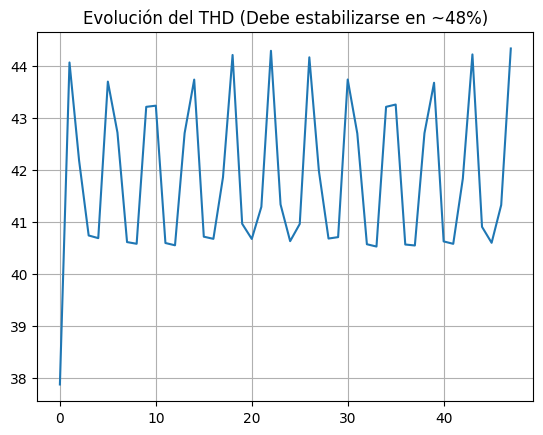

In [180]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# --- 1. CONFIGURACIÓN ---
fs = 10000
BUFFER_SIZE = 1024
OFFSET = 2048
duration = 5.0 # Aumentado para ver estabilidad

# --- 2. SEÑAL CUADRADA ---
t = np.arange(0, duration, 1/fs)
f0 = 50
x_cont = signal.square(2 * np.pi * f0 * t)
x_adc = (x_cont * 1500 + OFFSET).astype(np.uint16)

# --- 3. DISEÑO DE FILTROS (NORMALIZADOS) ---
taps_y2 = signal.firwin(281, 1200, fs=fs, window='hamming')
# Subimos fc a 150Hz para asegurar ganancia 1 en 50Hz
taps_y3 = signal.firwin(281, 150, fs=fs, window='hamming')

# NORMALIZACIÓN DE COEFICIENTES (Clave para evitar overflow de ganancia)
taps_y2 = taps_y2 / np.sum(taps_y2)
taps_y3 = taps_y3 / np.sum(taps_y3)

# --- 4. VARIABLES DE ESTADO ---
state_comb = np.zeros(200)
ptr_comb = 0
state_y2 = np.zeros(len(taps_y2))
state_y3 = np.zeros(len(taps_y3))

def procesar_fir_c_style(sample, taps, state):
    for j in range(len(state)-1, 0, -1):
        state[j] = state[j-1]
    state[0] = sample
    return np.dot(state, taps)

def my_app_simulation(adc_buffer):
    global ptr_comb, state_comb, state_y2, state_y3
    y1, y2, y3 = np.zeros(BUFFER_SIZE), np.zeros(BUFFER_SIZE), np.zeros(BUFFER_SIZE)
    
    alpha, beta = 2/11, 9/11
    
    # --- CHEQUEO DE OVERFLOW EN EL COMB ---
    # La ganancia máxima de este filtro es alpha/(1-beta) = 1.0
    
    for i in range(BUFFER_SIZE):
        x_n = float(adc_buffer[i]) - OFFSET
        
        y1_n = alpha * x_n + beta * state_comb[ptr_comb]
        state_comb[ptr_comb] = y1_n
        ptr_comb = (ptr_comb + 1) % 200
        y1[i] = y1_n
        
        y2[i] = procesar_fir_c_style(y1_n, taps_y2, state_y2)
        y3[i] = procesar_fir_c_style(y1_n, taps_y3, state_y3)
        
    # --- CHEQUEO DE RMS PARA EVITAR OVERFLOW EN SUMATORIA ---
    # En el MCU: sum_sq += y*y. Si sum_sq > 4.29e9 (en uint32), hay overflow.
    max_val_sq = np.max(y2**2)
    # Si max_val_sq * BUFFER_SIZE > Límite_Tipo_Dato -> PELIGRO
    
    vt_rms = np.sqrt(np.mean(y2**2))
    v0_rms = np.sqrt(np.mean(y3**2))
    
    thd = (np.sqrt(max(0, vt_rms**2 - v0_rms**2)) / v0_rms) * 100 if v0_rms > 1.0 else 0
    return thd, y1, y2, y3

# --- 6. EJECUCIÓN ---
num_bloques = len(x_adc) // BUFFER_SIZE
thd_evolucion = []

for b in range(num_bloques):
    bloque = x_adc[b*BUFFER_SIZE : (b+1)*BUFFER_SIZE]
    thd_v, y1_f, y2_f, y3_f = my_app_simulation(bloque)
    thd_evolucion.append(thd_v)

# --- 7. VERIFICACIÓN DE OVERFLOW Y RESULTADOS ---
print(f"--- Diagnóstico de señales (Último bloque) ---")
print(f"Máximo valor alcanzado en y1 (Comb): {np.max(np.abs(y1_f)):.2f}")
print(f"Amplitud Pico Fundamental (y3): {np.max(np.abs(y3_f)):.2f}")
print(f"Amplitud Pico Total con armónicos (y2): {np.max(np.abs(y2_f)):.2f}")
print(f"Relación y2/y3: {np.max(np.abs(y2_f))/np.max(np.abs(y3_f)):.4f}")

# Simulación de sumatoria RMS en 32 bits
sumatoria_cuadrados = np.sum(y2_f**2)
print(f"Valor de sumatoria para RMS: {sumatoria_cuadrados:.2e}")
if sumatoria_cuadrados > 4.29e9:
    print("ALERTA: Posible overflow en uint32_t si no usas float/double para la suma.")

print(f"\nTHD Final: {thd_evolucion[-1]:.2f}% (Esperado ~48.3%)")

plt.plot(thd_evolucion)
plt.title("Evolución del THD (Debe estabilizarse en ~48%)")
plt.grid(True)
plt.show()

In [184]:
def imprimir_taps_para_c(nombre, taps):
    print(f"const float {nombre}[{len(taps)}] = {{")
    for i, t in enumerate(taps):
        # El .8f es para no perder precisión, la 'f' es para el compilador de C
        print(f"    {t:.8f}f", end=",\n" if (i + 1) % 5 == 0 else ", ")
    print("\n};")

# Llamada con tus variables de la simulación
imprimir_taps_para_c("taps_FIR1", taps_y2)
imprimir_taps_para_c("taps_FIR2", taps_y3)

const float taps_FIR1[281] = {
    0.00054709f,     0.00085821f,     0.00108468f,     0.00119782f,     0.00118063f,
    0.00103018f,     0.00075842f,     0.00039142f,     -0.00003305f,     -0.00046940f,
    -0.00086900f,     -0.00118560f,     -0.00138062f,     -0.00142775f,     -0.00131636f,
    -0.00105329f,     -0.00066264f,     -0.00018373f,     0.00033281f,     0.00083032f,
    0.00125230f,     0.00154871f,     0.00168189f,     0.00163116f,     0.00139577f,
    0.00099569f,     0.00047004f,     -0.00012659f,     -0.00072977f,     -0.00127208f,
    -0.00169062f,     -0.00193417f,     -0.00196939f,     -0.00178513f,     -0.00139448f,
    -0.00083409f,     -0.00016091f,     0.00055352f,     0.00123057f,     0.00179310f,
    0.00217413f,     0.00232473f,     0.00222008f,     0.00186308f,     0.00128499f,
    0.00054292f,     -0.00028571f,     -0.00111112f,     -0.00184076f,     -0.00238960f,
    -0.00268987f,     -0.00269927f,     -0.00240656f,     -0.00183390f,     -0.00103553f,
    -

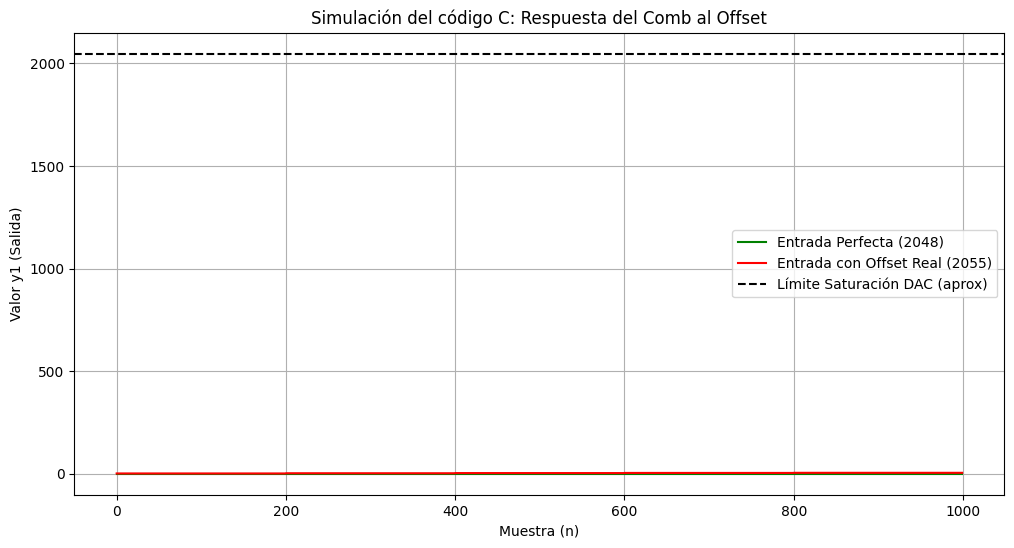

Último valor salida limpia: 0.00
Último valor salida con offset: 4.43


In [186]:
import numpy as np
import matplotlib.pyplot as plt

# --- CONFIGURACIÓN IGUAL AL C ---
BUFFER_SIZE = 1000
COMB_DELAY = 200
alpha = 0.181818
beta = 0.818181

# Simulamos el estado del filtro (el buffer circular)
state_comb = np.zeros(COMB_DELAY)
idx_comb = 0

def procesar_bloque_comb(adc_in_block):
    global idx_comb, state_comb
    y1 = np.zeros(BUFFER_SIZE)
    
    for i in range(BUFFER_SIZE):
        # 1. Casting y eliminación de offset fijo (Igual que en tu C)
        # Simulamos que el ADC tiene un pequeño error: 2050 en vez de 2048
        x_n = float(adc_in_block[i]) - 2048.0
        
        # 2. Tu ecuación de C:
        # y1[i] = alpha * x_n + beta * state_comb[idx_comb]
        # state_comb[idx_comb] = y1[i]
        
        # Leemos el retrasado
        delayed_val = state_comb[idx_comb]
        
        # Calculamos salida
        y1[i] = (alpha * x_n) + (beta * delayed_val)
        
        # Actualizamos estado
        state_comb[idx_comb] = y1[i]
        
        # Buffer circular
        idx_comb += 1
        if idx_comb >= COMB_DELAY:
            idx_comb = 0
            
    return y1

# --- SIMULACIÓN DE PRUEBA ---

# Caso A: Señal perfecta centrada en 2048
entrada_limpia = np.ones(BUFFER_SIZE) * 2048

# Caso B: Entrada con OFFSET (El ADC mide 2055 en vez de 2048)
# Solo 7 puntos de diferencia
entrada_con_offset = np.ones(BUFFER_SIZE) * 2055 

# Procesamos
salida_limpia = procesar_bloque_comb(entrada_limpia)
salida_offset = procesar_bloque_comb(entrada_con_offset)

# --- GRÁFICOS ---
plt.figure(figsize=(12, 6))

plt.plot(salida_limpia, label="Entrada Perfecta (2048)", color='green')
plt.plot(salida_offset, label="Entrada con Offset Real (2055)", color='red')

plt.axhline(y=2047, color='black', linestyle='--', label="Límite Saturación DAC (aprox)")
plt.title("Simulación del código C: Respuesta del Comb al Offset")
plt.xlabel("Muestra (n)")
plt.ylabel("Valor y1 (Salida)")
plt.grid(True)
plt.legend()
plt.show()

# Verificación de valores finales
print(f"Último valor salida limpia: {salida_limpia[-1]:.2f}")
print(f"Último valor salida con offset: {salida_offset[-1]:.2f}")

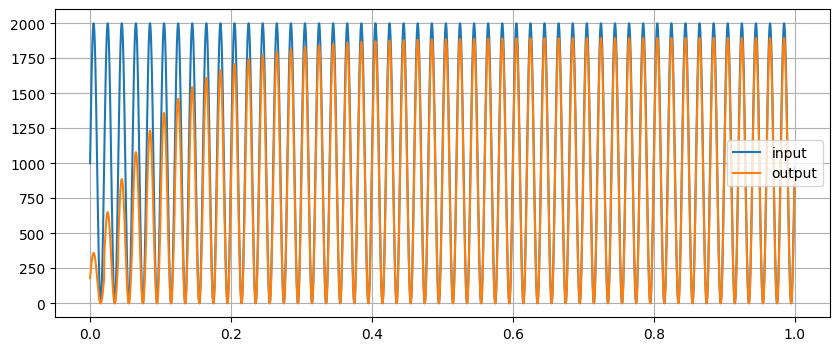

In [198]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros (los mismos que tu código)
fs = 10000
D = 200
alpha = 0.18
beta  = 0.81

N = 10000
t = np.arange(N)/fs

# Señal de prueba (probá cambiar frecuencia)
f0 = 50  # probá 50, 25, 100
x = 1000+1000*np.sin(2*np.pi*f0*t)  # amplitud similar a ADC

# Estado del comb
state = np.zeros(D)
idx = 0

y = np.zeros(N)

# Comb IIR
for n in range(N):
    delayed_y = state[idx]

    y[n] = alpha*x[n] + beta*delayed_y

    state[idx] = y[n]

    idx += 1
    if idx >= D:
        idx = 0

# Plot
plt.figure(figsize=(10,4))
plt.plot(t, x, label="input")
plt.plot(t, y, label="output")
plt.legend()
plt.grid()
plt.show()

In [210]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# --- Configuración idéntica al código C ---
BUFFER_SIZE = 1000
SAMPLE_RATE = 10000  # 10 kHz
COMB_DELAY = 200
ALPHA = 0.18181
BETA = 0.81818

def generate_inputs(filename, duration_sec=1.0):
    """Genera una señal de prueba: Seno de 50Hz + 3er armónico + Ruido"""
    t = np.arange(0, duration_sec, 1/SAMPLE_RATE)
    
    # Amplitudes para el cálculo del THD esperado
    # Fundamental (50Hz) y 3er Armónico (150Hz)
    amp_fund = 1000.0
    amp_harm = 300.0
    
    fundamental = amp_fund * np.sin(2 * np.pi * 50 * t)
    harmonico = amp_harm * np.sin(2 * np.pi * 150 * t)
    ruido = 50 * np.random.normal(size=len(t))
    
    signal_float = 2048 + fundamental + harmonico + ruido
    signal_uint16 = np.clip(signal_float, 0, 4095).astype(np.uint16)
    
    np.savetxt(filename, signal_uint16, fmt='%d')
    print(f"Archivo de entrada '{filename}' generado.")
    
    # Retornamos la señal y el THD teórico (armónico / fundamental)
    thd_teorico = amp_harm / amp_fund
    return signal_uint16, thd_teorico

def golden_model(input_signal, taps_fir1, taps_fir2):
    """Implementa la lógica del código C en Python"""
    x = input_signal.astype(float) - 2048.0
    
    # 1. Filtro Comb
    y1 = np.zeros_like(x)
    for n in range(len(x)):
        delayed_val = y1[n - COMB_DELAY] if n >= COMB_DELAY else 0
        y1[n] = ALPHA * x[n] + BETA * delayed_val
        
    # 2. Filtros FIR
    y2 = np.convolve(y1, taps_fir1, mode='same')
    y3 = np.convolve(y1, taps_fir2, mode='same')
    
    # 3. Cálculo de THD por bloques
    thd_output = []
    for i in range(0, len(y1), BUFFER_SIZE):
        block_y2 = y2[i:i+BUFFER_SIZE]
        block_y3 = y3[i:i+BUFFER_SIZE]
        
        if len(block_y2) < BUFFER_SIZE: break
        
        v0 = np.sqrt(np.mean(block_y3**2))
        vt = np.sqrt(np.mean(block_y2**2))
        
        # THD = sqrt(Vt^2 - V0^2) / V0
        thd = np.sqrt(np.abs(vt**2 - v0**2)) / v0 if v0 > 1e-6 else 0
        thd_output.extend([int(thd * 4095)] * len(block_y2))
        
    return thd_output

if __name__ == "__main__":
    # 1. Generar entrada y obtener THD teórico
    input_data, thd_esperado = generate_inputs("input_samples.txt")
    
    # 2. Diseño de filtros (usando SAMPLE_RATE definido arriba)
    fs = SAMPLE_RATE
    
    # FIR 1: Pasa-todo o banda ancha para Vt
    n2, beta2, fc2 = 281, 1.8, 530 
    taps_f1 = signal.firwin(n2, fc2, fs=fs, window=('kaiser', beta2))

    # FIR 2: Pasa-bajos para V0 (Fundamental)
    n3, beta3, fc3 = 281, 2.0, 75
    taps_f2 = signal.firwin(n3, fc3, fs=fs, window=('kaiser', beta3))
    
    # 3. Ejecutar modelo
    golden_result = golden_model(input_data, taps_f1, taps_f2)
    
    # 4. Calcular THD final obtenido (promedio de la salida del DAC)
    # Convertimos de escala 0-4095 de vuelta a flotante 0.0-1.0
    thd_final = np.mean(golden_result) / 4095.0
    
    # 5. Impresión de resultados
    print("\n" + "="*45)
    print(f"{'ANÁLISIS DE RESULTADOS (GOLDEN MODEL)':^45}")
    print("="*45)
    print(f"Frecuencia de Muestreo: {SAMPLE_RATE} Hz")
    print(f"THD Esperado (Teórico):  {thd_esperado:.4f} ({thd_esperado*100:.2f}%)")
    print(f"THD Final (Procesado):   {thd_final:.4f} ({thd_final*100:.2f}%)")
    print(f"Error absoluto:          {abs(thd_esperado - thd_final):.4f}")
    print("="*45)
    
    # 6. Guardar referencia
    np.savetxt("golden_reference.txt", golden_result, fmt='%d')
    print("Golden Reference generado en 'golden_reference.txt'.")

Archivo de entrada 'input_samples.txt' generado.

    ANÁLISIS DE RESULTADOS (GOLDEN MODEL)    
Frecuencia de Muestreo: 10000 Hz
THD Esperado (Teórico):  0.3000 (30.00%)
THD Final (Procesado):   0.2940 (29.40%)
Error absoluto:          0.0060
Golden Reference generado en 'golden_reference.txt'.


--- Verificación (Zona Estable: muestras 3000 a 10000) ---
Error máximo: 16.0 LSB
Error medio: 7.5714 LSB


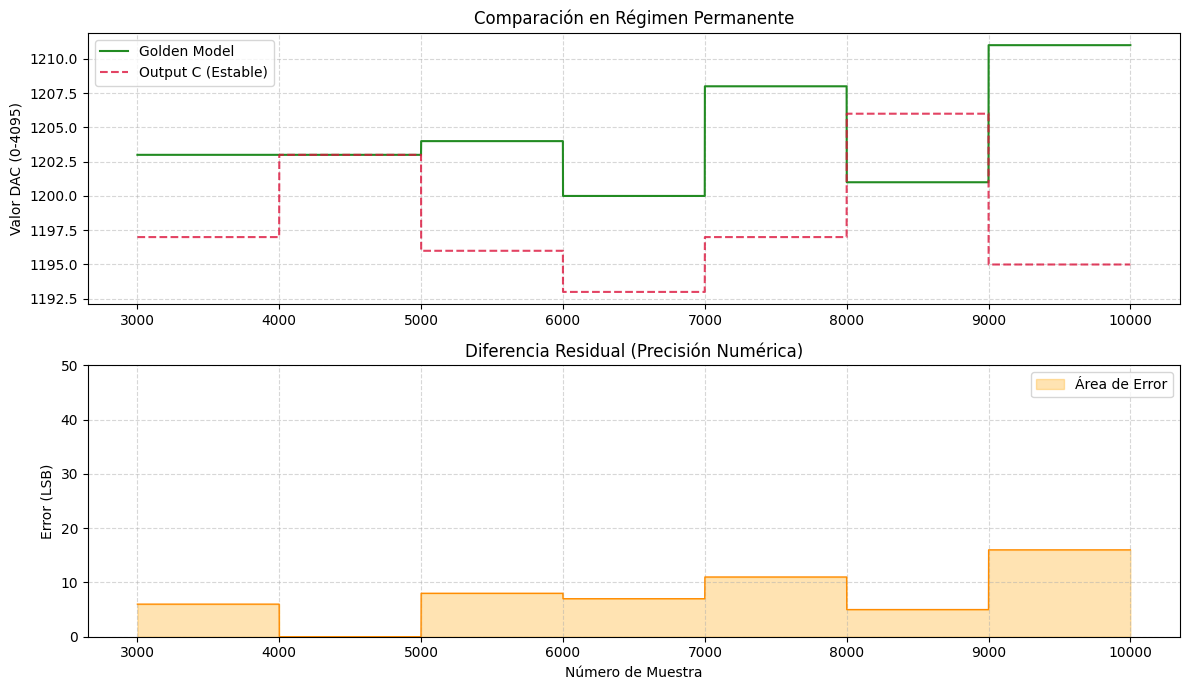

In [212]:
import numpy as np
import matplotlib.pyplot as plt

def verificar_estable(file_c, file_golden, samples_to_skip=3000):
    try:
        # 1. Cargar datos
        data_c = np.loadtxt(file_c)
        data_golden = np.loadtxt(file_golden)
        
        # Sincronizar tamaños
        min_len = min(len(data_c), len(data_golden))
        
        # 2. Recortar la parte del transitorio inicial
        # Saltamos las primeras N muestras (ej: 3000 muestras = 3 bloques)
        if min_len <= samples_to_skip:
            print("Error: El archivo es demasiado corto para saltar tantas muestras.")
            return

        c_estable = data_c[samples_to_skip:min_len]
        g_estable = data_golden[samples_to_skip:min_len]
        muestras = np.arange(samples_to_skip, min_len)

        # 3. Cálculo de error en zona estable
        error = np.abs(c_estable - g_estable)
        max_err = np.max(error)
        mean_err = np.mean(error)

        print(f"--- Verificación (Zona Estable: muestras {samples_to_skip} a {min_len}) ---")
        print(f"Error máximo: {max_err} LSB")
        print(f"Error medio: {mean_err:.4f} LSB")

        # 4. Gráfica limpia
        plt.figure(figsize=(12, 7))

        plt.subplot(2, 1, 1)
        plt.plot(muestras, g_estable, label='Golden Model', color='forestgreen', linewidth=1.5)
        plt.plot(muestras, c_estable, label='Output C (Estable)', color='crimson', linestyle='--', alpha=0.8)
        plt.title(f'Comparación en Régimen Permanente')
        plt.ylabel('Valor DAC (0-4095)')
        plt.legend()
        plt.grid(True, which='both', linestyle='--', alpha=0.5)

        plt.subplot(2, 1, 2)
        plt.fill_between(muestras, error, color='orange', alpha=0.3, label='Área de Error')
        plt.plot(muestras, error, color='darkorange', linewidth=1)
        plt.title('Diferencia Residual (Precisión Numérica)')
        plt.xlabel('Número de Muestra')
        plt.ylabel('Error (LSB)')
        plt.ylim(0, max(50, max_err + 5)) # Zoom en el error
        plt.legend()
        plt.grid(True, which='both', linestyle='--', alpha=0.5)

        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Error: {e}")

if __name__ == "__main__":
    # Ajusta samples_to_skip según necesites (3000 suele ser suficiente para tus FIR de 281)
    verificar_estable("salida_c.txt", "golden_reference.txt", samples_to_skip=3000)